# Fitting and inspecting a TRILEGAL population GMM

This notebook turns a set of TRILEGAL population-synthesis catalogues into a compact, correlated stellar-population model. The Gaussian mixture model (GMM) is a compressed density map: each Gaussian describes a locally ellipsoidal part of the population, while the complete mixture can follow curved features such as the main sequence and red-giant branch.

The fitted coordinates are

$$
\left(\log_{10} M,\ \log_{10} R,\ \log_{10} T_{\rm eff},\ [\mathrm{Fe/H}]\right).
$$

The workflow below:

1. finds and combines the TRILEGAL files;
2. applies the 1 kpc and temperature cuts;
3. checks the resulting stellar population;
4. compares several full-covariance GMMs on held-out stars;
5. examines whether the selected mixture reproduces important projections and narrow slices;
6. saves, reloads, samples, and evaluates the fitted model.

The current AsteroScale release does **not** yet pass this model to `Solver`. The final sections demonstrate the operations supported by the training model itself; solver integration is a separate development step.

## Installation and file layout

From the repository root, install the development version:

```bash
python -m pip install -e ".[test,docs]"
```

Place the TRILEGAL outputs in `data/trilegal/`, or set the `ASTEROSCALE_TRILEGAL_DIR` environment variable to their directory. The catalogues are inputs to an offline build and should not be committed to the repository.

The adapter expects a whitespace-separated table whose first non-empty line contains the column names. For the present workflow the output must include `Mact`, `logL`, `logTe`, `[M/H]`, and `m-M0`; `logAge` is optional but useful for diagnostics.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np

from asteroscale.training import (PopulationGMM,
                                  fit_candidate_models,
                                  read_trilegal,
                                  )


def find_repository_root(start):
    """Find the nearest parent containing AsteroScale's pyproject file."""
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find the AsteroScale repository root.")


repository_root = find_repository_root(Path.cwd())
data_directory = Path(os.environ.get("ASTEROSCALE_TRILEGAL_DIR",
                                     repository_root / 'asteroscale' / "data" / "trilegal",))

output_directory = repository_root / "population_models"
output_directory.mkdir(parents=True, exist_ok=True)

print("TRILEGAL directory:", data_directory)
print("Model output directory:", output_directory)

TRILEGAL directory: /home/ADF/nielsemb/work/repos/AsteroScale/asteroscale/data/trilegal
Model output directory: /home/ADF/nielsemb/work/repos/AsteroScale/population_models


## Load and normalize the simulations

Each of the 12 simulations covers the same area, so its Monte Carlo rows can be combined with equal weight. TRILEGAL has already drawn stars according to its IMF, star-formation histories, evolutionary dwell times, and Galactic density model; duplicating IMF or lifetime weights here would count those assumptions twice.

These particular simulations used TRILEGAL 1.6, 10 deg² fields, Gaia EDR3 photometry, $G<20$, $A_V(\infty)=0$, and a binary fraction of 0.3. Record whether binary components were printed separately or as one system entry, because that changes what one row represents.

The adapter calculates radius from luminosity and effective temperature:

$$
\frac{R}{R_\odot} = 10^{\log L/2}
\left(\frac{T_{{\rm eff},\odot}}{10^{\log T_{\rm eff}}}\right)^2.
$$

TRILEGAL supplies $[\mathrm{M/H}]$. AsteroScale currently stores this coordinate under the name `feh`; the equality $[\mathrm{M/H}]\simeq[\mathrm{Fe/H}]$ is an approximation for alpha-enhanced populations.

In [3]:
# Change the pattern if the downloaded files use another extension.
trilegal_paths = sorted(data_directory.glob("*.dat"))
if not trilegal_paths:
    raise FileNotFoundError(f"No .dat files found in {data_directory}. " 
                            "Place the outputs there or set ASTEROSCALE_TRILEGAL_DIR.")

print(f"Found {len(trilegal_paths)} files")
for path in trilegal_paths:
    print(" ", path.name)

catalogue = read_trilegal(trilegal_paths,
                          max_distance_pc=1000.0,
                          teff_range=(3500.0, 8000.0),
                          R_range=(0.09, 1000),
                          feh_kind="mh",
                          )

print(f"Retained {len(catalogue):,} stars after the cuts")

Found 11 files
  l135b+41.81.dat
  l135b-41.81.dat
  l180b+0.dat
  l225b+41.81.dat
  l225b-41.81.dat
  l270b+0.dat
  l315b+41.81.dat
  l315b-41.81.dat
  l45b+41.81.dat
  l45b-41.81.dat
  l90b+0.dat
Retained 20,913 stars after the cuts


## Check the adapted catalogue before fitting

A GMM will faithfully compress mistakes as well as real structure. Before fitting, inspect the ranges and the main physical projections. In particular, look for malformed columns, implausible radii, duplicated headers interpreted as rows, or a pointing that contributes a very different number of nearby stars from the others.

mass_Msun         : min=    0.109  p01=    0.179  median=    0.394  p99=     1.55  max=     3.74
radius_Rsun       : min=    0.116  p01=    0.188  median=    0.353  p99=     2.64  max=     95.8
teff_K            : min= 3.51e+03  p01= 3.51e+03  median= 3.88e+03  p99= 6.79e+03  max=    8e+03
metallicity_dex   : min=    -3.19  p01=    -0.93  median=    -0.15  p99=     0.37  max=     0.57


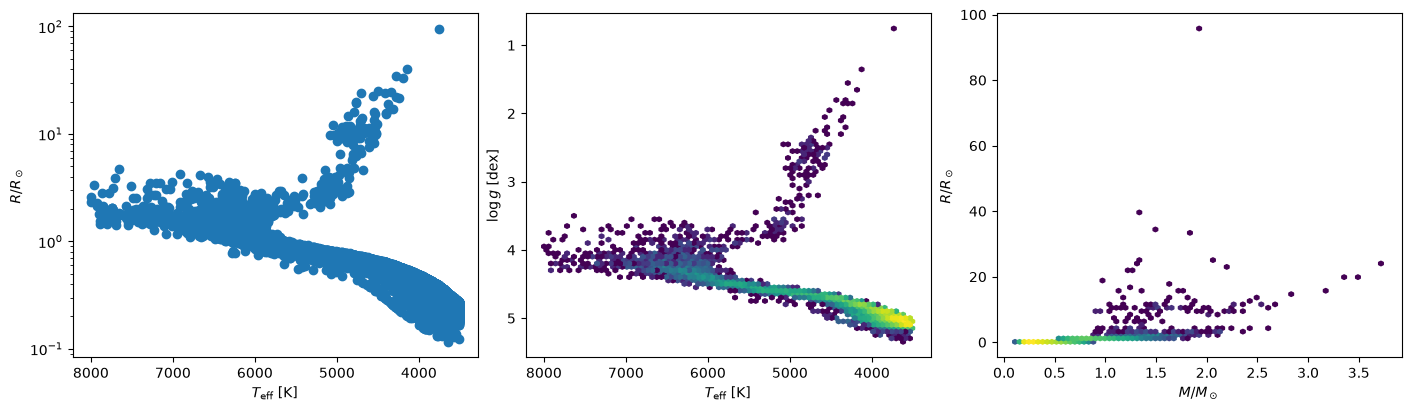

In [4]:
summary = {"mass_Msun": catalogue.mass,
           "radius_Rsun": catalogue.radius,
           "teff_K": catalogue.teff,
           "metallicity_dex": catalogue.feh,
           }

for name, values in summary.items():
    q = np.percentile(values, (0, 1, 50, 99, 100))
    print(f"{name:18s}: min={q[0]:9.3g}  p01={q[1]:9.3g}  "
          f"median={q[2]:9.3g}  p99={q[3]:9.3g}  max={q[4]:9.3g}")

logg = 4.438 + np.log10(catalogue.mass) - 2.0 * np.log10(catalogue.radius)

figure, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].scatter(catalogue.teff, catalogue.radius)
axes[0].set(xlabel=r"$T_{\rm eff}$ [K]", ylabel=r"$R/R_\odot$", yscale='log')
axes[0].invert_xaxis()

axes[1].hexbin(catalogue.teff, logg, gridsize=80, bins="log", mincnt=1)
axes[1].set(xlabel=r"$T_{\rm eff}$ [K]", ylabel=r"$\log g$ [dex]")
axes[1].invert_xaxis()
axes[1].invert_yaxis()

axes[2].hexbin(catalogue.mass, catalogue.radius, gridsize=80, bins="log", mincnt=1)
axes[2].set(xlabel=r"$M/M_\odot$", ylabel=r"$R/R_\odot$")
plt.show()

## Fit candidate mixtures

The fitter standardizes all four coordinates and uses weighted expectation-maximization with full covariance matrices. It reserves 20% of the rows for validation, then selects the smallest mixture whose held-out mean log density lies within `selection_tolerance` of the best candidate.

Start with `QUICK_RUN = True`. This is a pipeline check, not the final scientific model. Once the plots and metadata are correct, set it to `False` to compare up to 256 components. The final search can take substantially longer because its cost grows roughly with the number of stars, Gaussian components, initializations, and EM iterations.

In [11]:
QUICK_RUN = False

if QUICK_RUN:
    component_counts = (8, 16, 32)
    n_init = 2
    max_iter = 200
else:
    component_counts = (8, 16, 32, 64, 128, 256)
    n_init = 5
    max_iter = 500

model, candidate_report = fit_candidate_models(catalogue.coordinates,
                                               catalogue.weight,
                                               component_counts,
                                               validation_fraction=0.2,
                                               selection_tolerance=0.01,
                                               random_state=2026,
                                               n_init=n_init,
                                               max_iter=max_iter,
                                               reg_covar=1e-6,
                                               batch_size=10_000,
                                              )

model.metadata["catalogue"] = catalogue.metadata
model.metadata["generation"] = {"synthesis_code": "TRILEGAL",
                                "version": "1.6",
                                "field_area_deg2": 10.0,
                                "n_fields": len(trilegal_paths),
                                "photometric_system": "Gaia EDR3 (Vega)",
                                "limiting_magnitude_first_filter": 20.0,
                                "av_at_infinity_mag": 0.0,
                                "binary_fraction": 0.3,
                                "binary_output_representation": "VERIFY FROM SUBMITTED FORM",
                                "metallicity_note": "TRILEGAL [M/H] stored in the feh coordinate",
                                }

print("Selected components:", model.metadata["n_components"])
candidate_report

Selected components: 256


[{'n_components': 8,
  'validation_mean_log_density': 8.806185752934963,
  'bic': -292917.546011035},
 {'n_components': 16,
  'validation_mean_log_density': 9.508056775201227,
  'bic': -315822.42890641926},
 {'n_components': 32,
  'validation_mean_log_density': 9.977949469555066,
  'bic': -329072.8784808258},
 {'n_components': 64,
  'validation_mean_log_density': 10.217895469114508,
  'bic': -333771.378287427},
 {'n_components': 128,
  'validation_mean_log_density': 10.385219253560047,
  'bic': -332327.8535812417},
 {'n_components': 256,
  'validation_mean_log_density': 10.453064883335152,
  'bic': -323527.43874482915}]

The validation score should rise and then begin to plateau as components are added. BIC is useful context, but it is not the final scientific criterion: a small improvement in average density can still matter if it preserves a narrow, low-density evolutionary sequence.

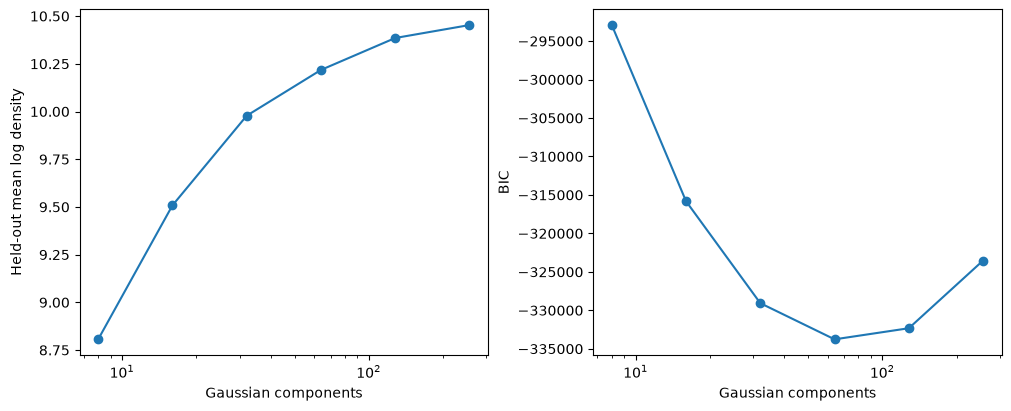

In [12]:
counts = np.array([row["n_components"] for row in candidate_report])
validation_score = np.array(
    [row["validation_mean_log_density"] for row in candidate_report]
)
bic = np.array([row["bic"] for row in candidate_report])

figure, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].plot(counts, validation_score, marker="o")
axes[0].set(
    xlabel="Gaussian components",
    ylabel="Held-out mean log density",
    xscale="log",
)
axes[1].plot(counts, bic, marker="o")
axes[1].set(xlabel="Gaussian components", ylabel="BIC", xscale="log")
plt.show()

## Compare catalogue stars with GMM draws

Global plots reveal gross failures, but they can hide excessive smoothing. The second figure therefore examines a narrow mass-metallicity slice. This is analogous to checking a map both from orbit and at street level: the full HR diagram tests the broad geography, while the slice tests whether a thin stellar sequence remains sharp.

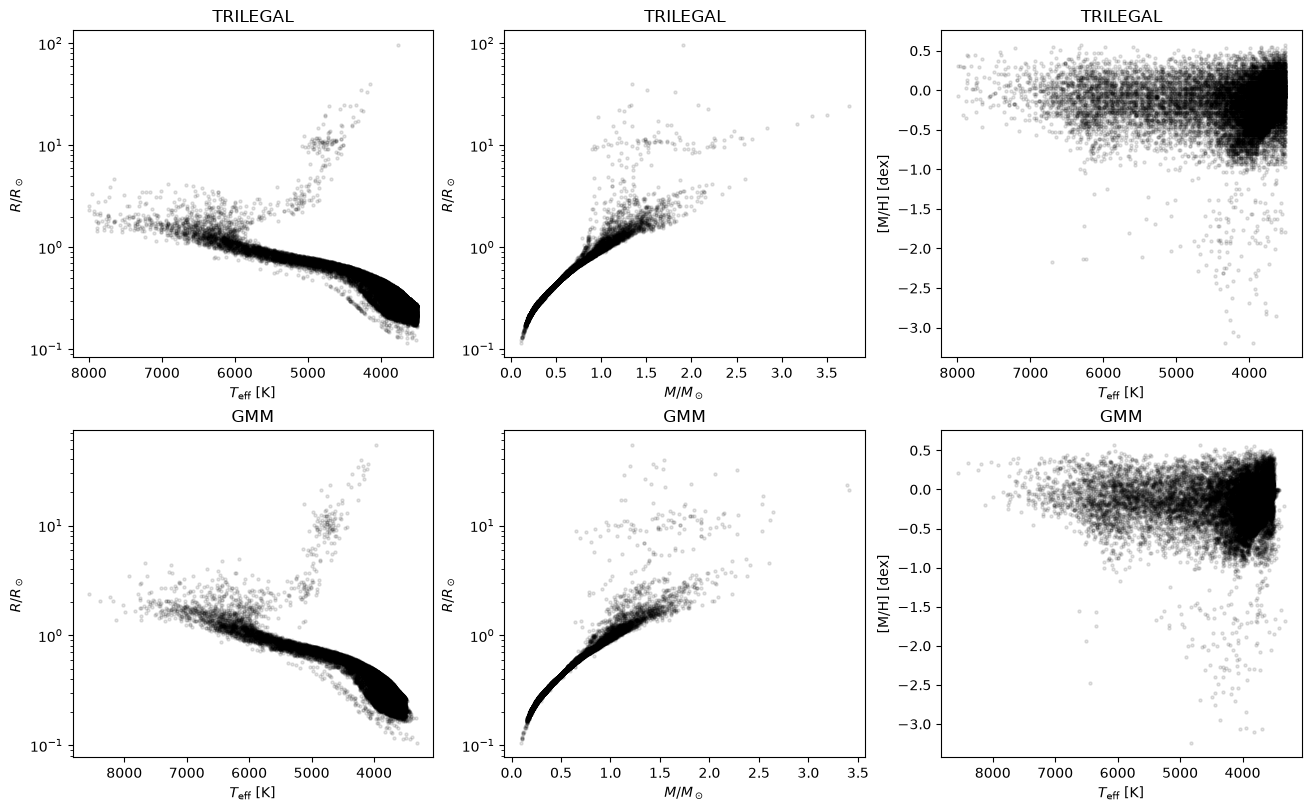

In [13]:
def physical_coordinates(coordinates):
    """Convert GMM coordinates to mass, radius, temperature, and metallicity."""
    coordinates = np.asarray(coordinates)
    return {
        "mass": 10.0 ** coordinates[:, 0],
        "radius": 10.0 ** coordinates[:, 1],
        "teff": 10.0 ** coordinates[:, 2],
        "feh": coordinates[:, 3],
    }


rng = np.random.default_rng(2026)
n_plot = min(len(catalogue), 100_000)
catalogue_indices = rng.choice(len(catalogue), size=n_plot, replace=False)
catalogue_plot = physical_coordinates(catalogue.coordinates[catalogue_indices])
gmm_plot = physical_coordinates(model.sample(n_plot, random_state=2026))

figure, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
pairs = (
    ("teff", "radius", r"$T_{\rm eff}$ [K]", r"$R/R_\odot$"),
    ("mass", "radius", r"$M/M_\odot$", r"$R/R_\odot$"),
    ("teff", "feh", r"$T_{\rm eff}$ [K]", r"$[\mathrm{M/H}]$ [dex]"),
)

for row, (label, values) in enumerate((("TRILEGAL", catalogue_plot), ("GMM", gmm_plot))):
    for axis, (x_name, y_name, x_label, y_label) in zip(axes[row], pairs):
        axis.scatter(values[x_name], values[y_name], alpha=0.1, color='k', s=5)
        axis.set(xlabel=x_label, ylabel=y_label, title=label)
        if y_name == "radius":
            axis.set_yscale("log")
        if x_name == "teff":
            axis.invert_xaxis()
plt.show()

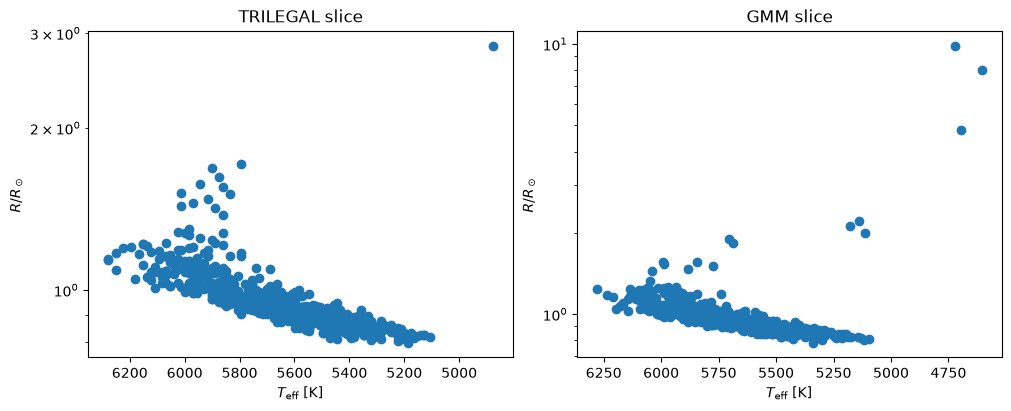

TRILEGAL stars in slice: 609
GMM draws in slice: 626


In [15]:
def solar_slice(values):
    return (
        (values["mass"] >= 0.9)
        & (values["mass"] <= 1.1)
        & (values["feh"] >= -0.2)
        & (values["feh"] <= 0.2)
    )


catalogue_slice = solar_slice(catalogue_plot)
gmm_slice = solar_slice(gmm_plot)

figure, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for axis, label, values, selection in (
    (axes[0], "TRILEGAL slice", catalogue_plot, catalogue_slice),
    (axes[1], "GMM slice", gmm_plot, gmm_slice),
):
    axis.scatter(
        values["teff"][selection],
        values["radius"][selection],
        # gridsize=55,
        # bins="log",
        # mincnt=1,
    )
    axis.set(
        xlabel=r"$T_{\rm eff}$ [K]",
        ylabel=r"$R/R_\odot$",
        title=label,
        yscale="log",
    )
    axis.invert_xaxis()
plt.show()

print("TRILEGAL stars in slice:", np.count_nonzero(catalogue_slice))
print("GMM draws in slice:", np.count_nonzero(gmm_slice))

Look for probability leaking between populated sequences or beyond visibly sharp edges. Increasing the component count can reduce leakage, but some boundaries are better represented explicitly. In particular, the red edge of the solar-like oscillation regime and survey detectability are selection or applicability functions, not boundaries of the underlying stellar population.

## Save and reload the model

The NPZ file contains only numerical arrays and JSON metadata, so it can be loaded with `allow_pickle=False`. The full TRILEGAL catalogue is not required after training.

In [16]:
model_path = output_directory / "trilegal_solar_neighbourhood_gmm.npz"
report_path = output_directory / "trilegal_solar_neighbourhood_gmm.json"

model.save(model_path)
report_path.write_text(
    json.dumps(
        {
            "model_path": str(model_path),
            "n_catalogue_rows": len(catalogue),
            "selected_components": model.metadata["n_components"],
            "candidate_results": candidate_report,
            "support_bounds": model.support_bounds.tolist(),
            "metadata": model.metadata,
        },
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

reloaded = PopulationGMM.load(model_path)
print("Saved:", model_path)
print("Components:", reloaded.metadata["n_components"])
print("Coordinate bounds:\n", reloaded.support_bounds)

Saved: /home/ADF/nielsemb/work/repos/AsteroScale/population_models/trilegal_solar_neighbourhood_gmm.npz
Components: 256
Coordinate bounds:
 [[-0.9625735   0.57310378]
 [-0.93534736  1.98115264]
 [ 3.545       3.903     ]
 [-3.19        0.57      ]]


## Sample from and evaluate the GMM

`sample` returns the four **transformed training coordinates**, not mass, radius, and temperature directly. Convert the first three columns back with powers of ten.

`logpdf` also expects transformed coordinates. Its value is the log density with respect to $(\log_{10}M,\log_{10}R,\log_{10}T_{\rm eff},[\mathrm{Fe/H}])$; it is not a density with respect to the three untransformed physical quantities.

In [17]:
prior_coordinates = reloaded.sample(20_000, random_state=44)
prior_stars = physical_coordinates(prior_coordinates)

for name, values in prior_stars.items():
    q16, q50, q84 = np.percentile(values, (16, 50, 84))
    print(f"{name:8s}: {q50:.4g}  ({q16:.4g}, {q84:.4g})")

solar_coordinates = np.array([0.0, 0.0, np.log10(5772.0), 0.0])
print("Solar-coordinate log density:", reloaded.logpdf(solar_coordinates))

mass    : 0.3974  (0.2464, 0.7867)
radius  : 0.356  (0.2441, 0.7195)
teff    : 3887  (3622, 4948)
feh     : -0.141  (-0.411, 0.09373)
Solar-coordinate log density: 6.410471911774139


A larger log density means that a point lies in a more densely populated part of this particular TRILEGAL model. It is not a goodness-of-fit statistic for an observed star by itself: an observational likelihood and the population prior answer different questions.

Before treating this as AsteroScale's default prior, repeat the comparison for:

- narrow mass and metallicity slices;
- main-sequence, subgiant, RGB, and core-helium-burning regions;
- the implied $\nu_{\max}$--$\Delta\nu$ distribution;
- different random train/validation splits;
- representative fields simulated to $G=22$ to check completeness within 1 kpc; and
- simulated observations, including posterior recovery and credible-interval coverage.

If the scientific diagnostics continue to improve at the largest tested component count, that count is a lower bound rather than a defensible final choice.

## Equivalent command-line fit

For a reproducible long run outside Jupyter, the same training machinery is available through the command line:

```bash
asteroscale-train-prior data/trilegal/*.dat \
    --adapter trilegal \
    --max-distance-pc 1000 \
    --teff-min 3500 \
    --teff-max 8000 \
    --components 8,16,32,64,128,256 \
    --validation-fraction 0.2 \
    --selection-tolerance 0.01 \
    --n-init 5 \
    --seed 2026 \
    --diagnostic-plot population_models/trilegal_gmm.png \
    --report population_models/trilegal_gmm.json \
    --output population_models/trilegal_gmm.npz
```

Add `--metadata settings.json` after converting the simulation record to JSON. The metadata should preserve the 12 Galactic coordinates, TRILEGAL 1.6 settings, binary representation, generation date, and citations.